In [148]:
import numpy as np
import xarray as xr
import h5py
from datetime import datetime 
import matplotlib.pyplot as plt

In [ ]:

year = 2018
dates = []
for month in range(1, 13):
    for day in range(1, 32):
        for hour in [0, 6, 12, 18]:
            try:
                date = datetime(year, month, day, hour)
                dates.append(date)
            except ValueError:
                # Skip invalid dates
                continue

dates = np.array(dates)

print(dates)
def find_date_idx(date):
    """
    Find the index of a date string in the dates array.
    """
    try:
        idx = np.where(dates == date)[0][0]
        return idx
    except IndexError:
        return None

IC_idx = find_date_idx(datetime(2018, 6, 30, 0))


[datetime.datetime(2018, 1, 1, 0, 0) datetime.datetime(2018, 1, 1, 6, 0)
 datetime.datetime(2018, 1, 1, 12, 0) ...
 datetime.datetime(2018, 12, 31, 6, 0)
 datetime.datetime(2018, 12, 31, 12, 0)
 datetime.datetime(2018, 12, 31, 18, 0)]


In [121]:
file = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010500_ens_1.nc"

In [122]:
ds = xr.open_dataset(file,engine='netcdf4')

In [123]:
ds

<xarray.Dataset> Size: 390MB
Dimensions:                        (time: 16, plev: 17, lat: 180, lon: 360)
Coordinates:
  * time                           (time) datetime64[ns] 128B 2018-01-05 ... ...
  * plev                           (plev) int64 136B 5 10 20 30 ... 850 925 1000
  * lat                            (lat) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * lon                            (lon) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables: (12/14)
    2m_temperature                 (time, lat, lon) float32 4MB ...
    10m_u_component_of_wind        (time, lat, lon) float32 4MB ...
    10m_v_component_of_wind        (time, lat, lon) float32 4MB ...
    mean_sea_level_pressure        (time, lat, lon) float32 4MB ...
    surface_pressure               (time, lat, lon) float32 4MB ...
    volumetric_soil_water_layer_1  (time, lat, lon) float32 4MB ...
    ...                             ...
    sea_surface_temperature        (time, lat, lon) float32 4MB ...
    temperature                    (time, plev, lat, lon) float32 71MB ...
    u_component_of_wind            (time, plev, lat, lon) float32 71MB ...
    v_component_of_wind            (time, plev, lat, lon) float32 71MB ...
    specific_humidity              (time, plev, lat, lon) float32 71MB ...
    geopotential                   (time, plev, lat, lon) float32 71MB ...
Attributes:
    description:  Prediction from pangu_plasim model run 1

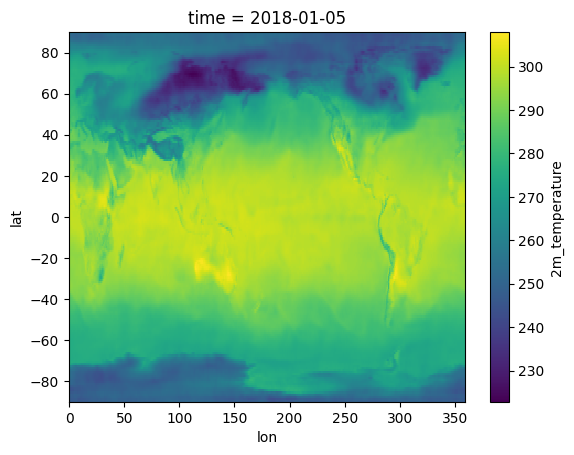

In [ ]:
# ds["2m_temperature"].mean(dim = ["lat","lon"]).plot()
fcst = ds["2m_temperature"].values
ds["2m_temperature"][0].plot(cmap="coolwarm))

In [147]:
dataset

array([[249.30473, 249.31023, 249.3146 , ..., 249.27954, 249.28851,
        249.29706],
       [250.12613, 250.14134, 250.15556, ..., 250.06398, 250.08513,
        250.1063 ],
       [250.97946, 250.97304, 250.96637, ..., 250.9056 , 250.93353,
        250.96078],
       ...,
       [248.02863, 247.93907, 247.84958, ..., 248.35269, 248.2439 ,
        248.13496],
       [247.8662 , 247.82698, 247.7892 , ..., 248.01187, 247.96346,
        247.91415],
       [247.83905, 247.81502, 247.78886, ..., 247.8875 , 247.87198,
        247.85603]], dtype=float32)

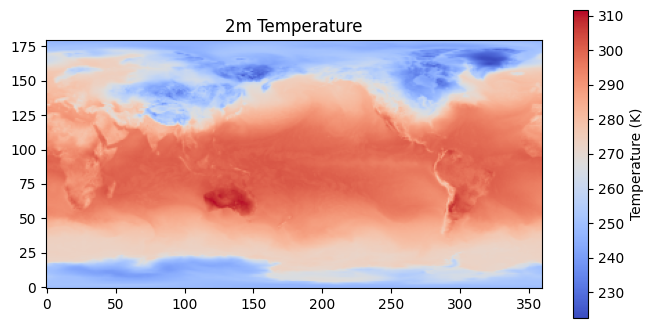

In [152]:
plt.figure(figsize=(8, 4))
plt.imshow(dataset, cmap="coolwarm", origin="lower")
plt.colorbar(label="Temperature (K)")
plt.title("2m Temperature")
plt.show()

In [141]:
dates_exp = ds["time"].values

In [142]:
dates

array([datetime.datetime(2018, 1, 1, 0, 0),
       datetime.datetime(2018, 1, 1, 6, 0),
       datetime.datetime(2018, 1, 1, 12, 0), ...,
       datetime.datetime(2018, 12, 31, 6, 0),
       datetime.datetime(2018, 12, 31, 12, 0),
       datetime.datetime(2018, 12, 31, 18, 0)], dtype=object)

In [128]:
#Get the string of the ground truth date
dates_str = []
for date in dates_exp:
    dates_str.append(date.astype('datetime64[ms]').astype(object).strftime("%Y%m%d%H"))

In [131]:
dates_exp[1].astype('datetime64[ms]').astype(object)

datetime.datetime(2018, 1, 6, 0, 0)

In [134]:
# Get the index of the ground truth date
gt_files = []
for date_exp in dates_exp:
    date_idx = find_date_idx(date_exp.astype('datetime64[ms]').astype(object))
    gt_file = "/project/pedramh/h5data/h5data/2018_{:04d}.h5".format(date_idx)
    gt_files.append(gt_file)
    

In [135]:
gt_files[0]

'/project/pedramh/h5data/h5data/2018_0016.h5'

In [153]:
#Get the ground truth files
# Open file in read-only mode
with h5py.File(gt_files[0], "r") as f:
    # List all groups
    print("Keys:", list(f['input'].keys()))  # Display first 10 entries
    dataset = f['input']["2m_temperature"][:]
    print("dataset shape:", dataset.shape)
    print("fcst:", fcst.shape)
    #print("Keys:", list(dataset.keys()))  # Display first 10 entries
    rmse = np.sqrt(np.mean((fcst[0] - dataset) ** 2))
    print("RMSE:", rmse)


Keys: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_dewpoint_temperature', '2m_temperature', 'geopotential_10.0', 'geopotential_100.0', 'geopotential_1000.0', 'geopotential_150.0', 'geopotential_20.0', 'geopotential_250.0', 'geopotential_30.0', 'geopotential_300.0', 'geopotential_400.0', 'geopotential_5.0', 'geopotential_50.0', 'geopotential_500.0', 'geopotential_600.0', 'geopotential_70.0', 'geopotential_700.0', 'geopotential_850.0', 'geopotential_925.0', 'geopotential_at_surface', 'land_sea_mask', 'maximum_2m_temperature_since_previous_post_processing', 'mean_sea_level_pressure', 'mean_top_net_long_wave_radiation_flux', 'minimum_2m_temperature_since_previous_post_processing', 'sea_ice_cover', 'sea_surface_temperature', 'skin_temperature', 'snow_depth', 'soil_temperature_level_1', 'specific_humidity_10.0', 'specific_humidity_100.0', 'specific_humidity_1000.0', 'specific_humidity_150.0', 'specific_humidity_20.0', 'specific_humidity_250.0', 'specific_humidity_30.0', 'specif

In [115]:
ds["temperature"].mean(dim = ["lat","lon"]).shape

(16, 17)

In [59]:
import os
if os.path.exists(gt_file):
    print("File exists!")
else:
    print("File not found.")

File exists!


In [ ]:
#find the gorund truth file 

array([datetime.datetime(2018, 1, 1, 0, 0),
       datetime.datetime(2018, 1, 1, 6, 0),
       datetime.datetime(2018, 1, 1, 12, 0), ...,
       datetime.datetime(2018, 12, 31, 6, 0),
       datetime.datetime(2018, 12, 31, 12, 0),
       datetime.datetime(2018, 12, 31, 18, 0)], dtype=object)

In [103]:
dates[0].strftime("%Y%m%d%H")

'2018010100'

In [9]:
files = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_{}_ens_*.nc".format(dates[0].strftime("%Y%m%d%H"))

In [10]:
import glob
ens_files = glob.glob(files)

In [11]:
ens_files

['/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_21.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_10.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_24.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_18.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_12.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_23.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_15step_2018010100_ens_22.nc',
 '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24

In [ ]:
#Get the ground truth 
